In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models
import torchvision.transforms as transforms
import numpy as np
import cv2 as cv
from PIL import Image
import os
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

cv.setNumThreads(0)

device='cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")
print(torch.cuda.get_device_name(0))

Using: cuda
Tesla T4


In [2]:
BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_CLASSES = 4

In [8]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

TRAIN_DIR = "/kaggle/input/brain-tumor-mri-dataset/Training"
TEST_DIR = "/kaggle/input/brain-tumor-mri-dataset/Testing"

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [10]:
class CustomDataset(Dataset):
    def __init__(self,data_dir,transform):
        self.data_dir=data_dir
        self.transform=transform
        self.images=[]
        self.labels=[]

        self.class_to_idx = {"glioma": 0, "meningioma": 1, "notumor": 2, "pituitary": 3}

        print("Scanning for images in class folders...")

        for class_name,class_idx in self.class_to_idx.items():
            class_dir=os.path.join(data_dir,class_name)

            class_images=0

            for image in os.listdir(class_dir):
                if image.endswith(('.jpeg', '.jpg', '.png')):
                    img_path=os.path.join(class_dir, image)
                    self.images.append(img_path)
                    self.labels.append(class_idx)
                    class_images+=1

        print(f"Total Images Loaded:{len(self.images)}")

    def __len__(self):
        return len(self.images)


    def mri_preprocessing(self,image):
        #contour cropping the tumour
        gray=cv.cvtColor(image,cv.COLOR_RGB2GRAY)
        gray=cv.GaussianBlur(gray,(5,5),0)
        thresh = cv.threshold(gray, 45, 255, cv.THRESH_BINARY)[1]
        cnts = cv.findContours(thresh.copy(), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        cnts = cnts[0] if len(cnts) == 2 else cnts[1]

        if cnts:
            c=max(cnts,key=cv.contourArea)
            x, y, w, h = cv.boundingRect(c)
            image = image[y:y+h, x:x+w]

        #enhancing contrast
        gray_cropped = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
        clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        res = clahe.apply(gray_cropped)
        return cv.cvtColor(res, cv.COLOR_GRAY2RGB)

    def __getitem__(self, index):
        image_path=self.images[index]
        label=self.labels[index]

        image=cv.imread(image_path)

        if image is None:
            raise FileNotFoundError(f"Failed to load image at: {image_path}")

        image=cv.cvtColor(image,cv.COLOR_BGR2RGB)
        image = self.mri_preprocessing(image)
        image = Image.fromarray(image)


        if self.transform:
            image=self.transform(image)

        return image,label


Scanning for images in class folders...
Total Images Loaded:5600


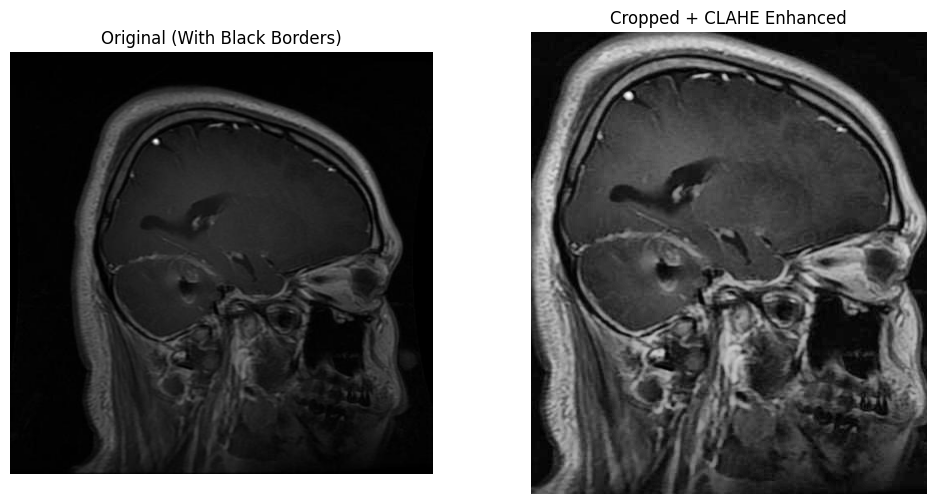

In [11]:

test_ds = CustomDataset(data_dir=TRAIN_DIR, transform=None)
raw_cv_img = cv.imread(test_ds.images[0])
raw_cv_img = cv.cvtColor(raw_cv_img, cv.COLOR_BGR2RGB)

# Process it
processed_img = test_ds.mri_preprocessing(raw_cv_img)

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(raw_cv_img)
plt.title("Original (With Black Borders)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(processed_img)
plt.title("Cropped + CLAHE Enhanced")
plt.axis('off')

plt.show()

In [12]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [19]:

train = CustomDataset(
    data_dir=TRAIN_DIR,
    transform=train_transforms
)

train_val = CustomDataset(
    data_dir=TRAIN_DIR,
    transform=val_transforms
)

test = CustomDataset(
    data_dir=TEST_DIR,
    transform=val_transforms
)


train_size = int(0.8 * len(train))
val_size = len(train) - train_size

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    len(train),
    generator=generator
)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = torch.utils.data.Subset(
    train,
    train_indices
)

val_subset = torch.utils.data.Subset(
    train_val,
    val_indices
)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test)}")

Scanning for images in class folders...
Total Images Loaded:5600
Scanning for images in class folders...
Total Images Loaded:5600
Scanning for images in class folders...
Total Images Loaded:1600
Training samples: 4480
Validation samples: 1120
Test samples: 1600


In [20]:
train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

print(f"Training batches per epoch: {len(train_loader)}")

val_loader = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

print(f"Validation batches per epoch: {len(val_loader)}")

test_loader = DataLoader(
        test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

print(f"Test batches: {len(test_loader)}")

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(test)}")
print(f"Number of classes: {NUM_CLASSES}")


Training batches per epoch: 140
Validation batches per epoch: 35
Test batches: 50
Training samples: 4480
Validation samples: 1120
Test samples: 1600
Number of classes: 4


In [22]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 4)
)

model = model.to(device)


In [23]:
from torchsummary import summary

summary(model, (3, 128, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 64, 64, 128]           9,408
       BatchNorm2d-2          [-1, 64, 64, 128]             128
              ReLU-3          [-1, 64, 64, 128]               0
         MaxPool2d-4           [-1, 64, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          36,864
       BatchNorm2d-6           [-1, 64, 32, 64]             128
              ReLU-7           [-1, 64, 32, 64]               0
            Conv2d-8           [-1, 64, 32, 64]          36,864
       BatchNorm2d-9           [-1, 64, 32, 64]             128
             ReLU-10           [-1, 64, 32, 64]               0
       BasicBlock-11           [-1, 64, 32, 64]               0
           Conv2d-12           [-1, 64, 32, 64]          36,864
      BatchNorm2d-13           [-1, 64, 32, 64]             128
             ReLU-14           [-1, 64,

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

sheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [26]:
def train_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    batch_num = 0
    for images, labels in tqdm(dataloader, desc="Training", leave=False):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        batch_num += 1
        if batch_num % 10 == 0:
            batch_acc = 100 * correct / total
            batch_loss = running_loss / total
            print(
                f"Batch {batch_num}/{len(dataloader)}, Loss: {batch_loss:.4f}, Acc: {batch_acc:.2f}%"
            )

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc
def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(f"Validation complete - {correct}/{total} samples correct")

    return epoch_loss, epoch_acc

In [27]:
training_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0

print("Starting Training")

for epoch in range(NUM_EPOCHS):

    current_lr = optimizer.param_groups[0]["lr"]
    print(f" Current learning rate: {current_lr:.6f}")

    print("TRAINING PHASE:")
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )

    print("VALIDATION PHASE:")
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    training_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("EPOCH SUMMARY")
    print(f"Training - Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"Validation - Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%")

    if epoch > 0:
        train_loss_change = training_losses[-1] - training_losses[-2]
        val_acc_change = val_accs[-1] - val_accs[-2]
        print(f"Train Loss: {train_loss_change:+.4f} | Val Acc: {val_acc_change:+.2f}%")

        print("Updating learing rate")
        old_lr = optimizer.param_groups[0]["lr"]
        sheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]

        if new_lr < old_lr:
            print(f"Learning rate reduced {old_lr:.6f} - {new_lr:.6f}")

        if val_acc > best_val_acc:
            improvement = val_acc - best_val_acc
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_brain_tumor_model.pth")

    print("TRAINING COMPLETED")
    print(f"Best Validation Accuracy: {best_val_acc}")

Starting Training
 Current learning rate: 0.001000
TRAINING PHASE:


Training:   7%|▋         | 10/140 [00:05<01:09,  1.87it/s]

Batch 10/140, Loss: 1.2319, Acc: 45.00%


Training:  14%|█▍        | 20/140 [00:11<01:09,  1.72it/s]

Batch 20/140, Loss: 1.0947, Acc: 52.81%


...

Batch 120/140, Loss: 0.3044, Acc: 88.52%


Training:  93%|█████████▎| 130/140 [00:42<00:03,  3.31it/s]

Batch 130/140, Loss: 0.2988, Acc: 88.73%


Batch 140/140, Loss: 0.2995, Acc: 88.50%
VALIDATION PHASE:


Validation complete - 997/1120 samples correct
EPOCH SUMMARY
Training - Loss: 0.2995 | Accuracy: 88.50%
Validation - Loss: 0.2692 | Accuracy: 89.02%
Train Loss: -0.0049 | Val Acc: -0.54%
Updating learing rate
TRAINING COMPLETED
Best Validation Accuracy: 89.73214285714286


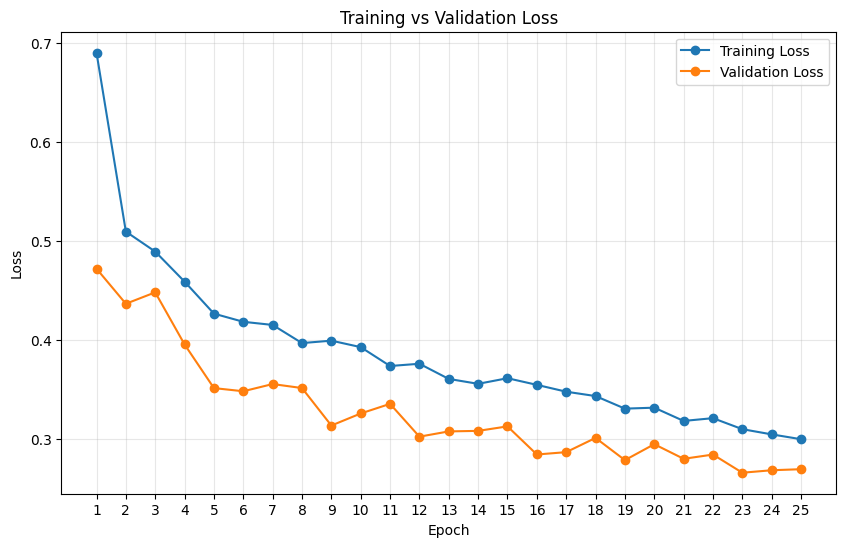

In [29]:
epochs = range(1, len(training_losses) + 1)


plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    training_losses,
    marker='o',
    label='Training Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


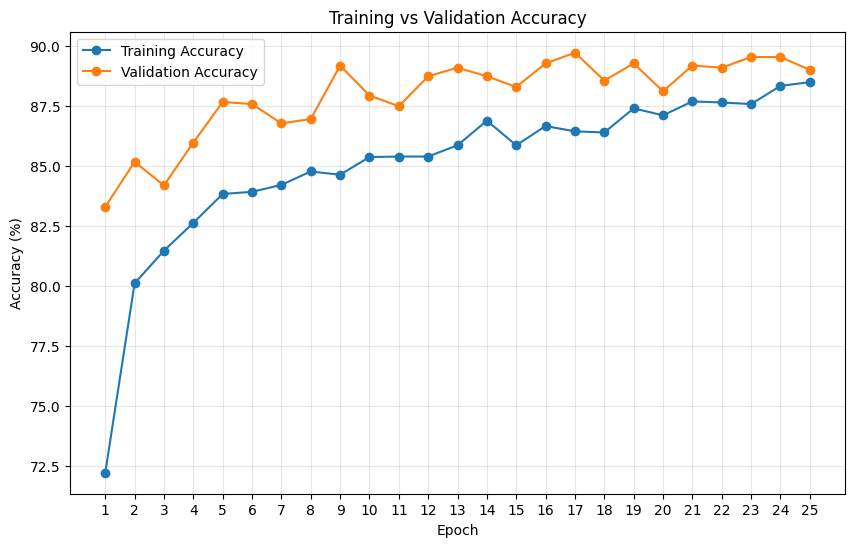

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_accs,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_accs,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.xticks(epochs)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [31]:
def evaluate_model(model, dataloader, device):

        print("Evaluating model on test set...")

        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in tqdm(dataloader, desc="Testing"):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print(f"Evaluated {len(all_labels)} test samples")
        return np.array(all_preds), np.array(all_labels)

print("Evaluating on test set")

test_preds, test_labels = evaluate_model(model, test_loader, device)

test_accuracy = 100 * np.sum(test_preds == test_labels) / len(test_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

class_names = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

Evaluating on test set
Evaluating model on test set...


Testing: 100%|██████████| 50/50 [00:24<00:00,  2.02it/s]

Evaluated 1600 test samples
Test Accuracy: 84.19%
Classification Report:
              precision    recall  f1-score   support

      Glioma       0.89      0.70      0.79       400
  Meningioma       0.75      0.74      0.74       400
    No Tumor       0.81      0.99      0.89       400
   Pituitary       0.93      0.94      0.94       400

    accuracy                           0.84      1600
   macro avg       0.85      0.84      0.84      1600
weighted avg       0.85      0.84      0.84      1600



In [32]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": [
        "Glioma",
        "Meningioma",
        "Pituitary",
        "No Tumor"
    ],
    "input_size": 224
}, "best_brain_tumor_resnet18.pth")

In [33]:
checkpoint = torch.load(
    "best_brain_tumor_resnet18.pth",
    map_location="cpu"
)

print(checkpoint.keys())

dict_keys(['model_state_dict', 'class_names', 'input_size'])


In [34]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=None)

model.fc = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 4)
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded successfully")

Model loaded successfully
